<a href="https://colab.research.google.com/github/bestianello88/ANALISI_VINO/blob/main/VINEQUALITY_DATASET.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Selfwork DA

Il “Wine Quality Dataset” , composto da due csv, offre un’opportunità per esplorare come le caratteristiche chimiche dei vini influenzino la loro qualità percepita. Attraverso l’analisi dei dati il committente chiede di identificare pattern, correlazioni e potenziali anomalie, acquisendo una comprensione più profonda dei fattori che contribuiscono alla qualità del vino.

- Quali caratteristiche chimiche hanno la maggiore influenza sulla qualità del vino?
- Esistono differenze significative tra i vini rossi e bianchi in termini di caratteristiche chimiche e qualità?
- Come variano le caratteristiche chimiche in base alle diverse fasce di qualità del vino?

In [ ]:
# Il csv è separato da ';' e non da ',' per leggerlo correttamente utilizzare il parametro sep=';' nella funzione read_csv

# **DATA EXPLORATION (EDA)** ⛑

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

ds_red = pd.read_csv('/content/2025-05-23-v0525-dataset-wine-red-datasetcsv.csv', sep=';')

ds_white = pd.read_csv('/content/2025-05-23-v0525-dataset-wine-white-datasetcsv.csv', sep=';')


ds_red['wine_type'] = 'red'

ds_white['wine_type'] = 'white'


ds = pd.concat([ds_red, ds_white], ignore_index=True)

print('\n')

print(f'Head del DS ')

display (ds.head())

print('\n')

print(f'Tail del DS ')

display (ds.tail())

print('\n')

print(f'Info del DS ')

display (ds.info())

print('\n')

print(f'Describe del ds_red')

display (ds_red.describe().T)

print('\n')

print(f'Describe del ds_white')

display (ds_white.describe().T)

print('\n')

print(f'DS shape: ')

display(ds.shape)

print('\n')

print(f'Valori nulli del DS ')

print(ds.isnull().sum())

print('\n')

print(f'Describe del DS ')

print(ds.describe().T)


#Inserimento del nome delle colonne  di ds in una lista chiamata cols

cols= list(ds.columns)

print('\n')

types= ds.dtypes
display(types)

print('\n')

ds.dtypes.value_counts()

print('\n')

ds.dtypes[ds.dtypes == 'object']

df = ds.copy()

num_cols = list(df.dtypes[df.dtypes != 'object'].keys())


cat_cols = list(df.dtypes[df.dtypes == 'object'].keys())


print(f'Numero colonne numeriche: {len(num_cols)}')

print(f'Numero colonne categoriche: {len(cat_cols)}')

print('\n')

display (df[cat_cols].describe())

print('\n')

# Cicli for di studio del dataset

for col in cat_cols:
    print(f"Valori unici per la colonna {col}:")
    print(df[col].unique())
    print('\n')

for col in cat_cols:
    print(f"Conteggio valori per la colonna {col}:")
    print(df[col].value_counts())
    print('\n')


# Aggregazione per media alcolica di qualità e tipo di vino (alcohol vs quality vs wine_type)

print(f'Più la qualità di vino è buona e maggiore sembra essere il tasso alcolico in tutte e due le categorie di vino, tranne che per vini di qualità 5')
pd.options.display.float_format = '{:.1f}'.format
quality_a = df.groupby(['wine_type','quality']) ['alcohol'].agg(['count', 'mean'])

display(quality_a)

print('\n')

# Aggregazione per pH e Density (min, max, mean)
print(f'Aggregazione per pH e Density (min, max, mean)')

ph_dens= df.groupby('wine_type').agg({
    'pH': ['min', 'max', 'mean'],
    'density': ['min', 'max', 'mean']})
display (ph_dens)

print('\n')

# Aggregazione e analisi dei solfati per tipologia di vino
print(f'Aggregazione e analisi dei solfati per tipologia di vino')

analisi_solfati = df.groupby(['wine_type', 'quality'])['sulphates'].agg(['count', 'mean'])
display(analisi_solfati)

print('\n')

# Stampa delle percentuali di vini rossi e bianchi

print(f"Percentuale di vini rossi: {df['wine_type'].value_counts(normalize=True)['red'] * 100:.1f}%")

print('\n')

print(f"Percentuale di vini bianchi: {df['wine_type'].value_counts(normalize=True)['white'] * 100:.1f}%")

print('\n')

# Visualizzazione dei valori Mancanti

missing_values= df.isnull().sum()

print(f'Valori mancanti: {missing_values}')



Head del DS 


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine_type
0,7.4,0.7,0.0,1.9,0.1,11.0,34.0,1.0,3.5,0.6,9.4,5,red
1,7.8,0.9,0.0,2.6,0.1,25.0,67.0,1.0,3.2,0.7,9.8,5,red
2,7.8,0.8,0.0,2.3,0.1,15.0,54.0,1.0,3.3,0.7,9.8,5,red
3,11.2,0.3,0.6,1.9,0.1,17.0,60.0,1.0,3.2,0.6,9.8,6,red
4,7.4,0.7,0.0,1.9,0.1,11.0,34.0,1.0,3.5,0.6,9.4,5,red




Tail del DS 


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine_type
6492,6.2,0.2,0.3,1.6,0.0,24.0,92.0,1.0,3.3,0.5,11.2,6,white
6493,6.6,0.3,0.4,8.0,0.0,57.0,168.0,1.0,3.1,0.5,9.6,5,white
6494,6.5,0.2,0.2,1.2,0.0,30.0,111.0,1.0,3.0,0.5,9.4,6,white
6495,5.5,0.3,0.3,1.1,0.0,20.0,110.0,1.0,3.3,0.4,12.8,7,white
6496,6.0,0.2,0.4,0.8,0.0,22.0,98.0,1.0,3.3,0.3,11.8,6,white




Info del DS 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  wine_type             6497 non-null   object 
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


...



Aggregazione per pH e Density (min, max, mean)


pH          density         
          min max mean     min max mean
wine_type                              
red       2.7 4.0  3.3     1.0 1.0  1.0
white     2.7 3.8  3.2     1.0 1.0  1.0



Aggregazione e analisi dei solfati per tipologia di vino


count  mean
wine_type quality             
red       3           10   0.6
          4           53   0.6
          5          681   0.6
          6          638   0.7
          7          199   0.7
          8           18   0.8
white     3           20   0.5
          4          163   0.5
          5         1457   0.5
          6         2198   0.5
          7          880   0.5
          8          175   0.5
          9            5   0.5



Percentuale di vini rossi: 24.6%


Percentuale di vini bianchi: 75.4%


Valori mancanti: fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
wine_type               0
dtype: int64


# **DATA MANIPULATION E VISUALIZATION**



- Quali caratteristiche chimiche hanno la maggiore influenza sulla qualità del vino?
- Esistono differenze significative tra i vini rossi e bianchi in termini di caratteristiche chimiche e qualità?
- Come variano le caratteristiche chimiche in base alle diverse fasce di qualità del vino?

(6497, 13)
(6497, 13)
Tabella Pivot della qualità legata alla media Alcolica




wine_type,red,white
quality,,
3,10.0,10.3
4,10.3,10.2
5,9.9,9.8
6,10.6,10.6
7,11.5,11.4
8,12.1,11.6
9,NaN,12.2


Tabella Pivot della qualità legata alla media dei Solfiti




wine_type,red,white
quality,,
3,0.6,0.5
4,0.6,0.5
5,0.6,0.5
6,0.7,0.5
7,0.7,0.5
8,0.8,0.5
9,NaN,0.5


Tabella Pivot della qualità legata alla media della Acidità Volatile




...



Comparazione Qualità per Media di Acido Citrico


wine_type,red,white
quality,,
3,0.2,0.3
4,0.2,0.3
5,0.2,0.3
6,0.3,0.3
7,0.4,0.3
8,0.4,0.3
9,NaN,0.4




Tabella Pivot per Qualità legata alla media di Zucchero Residuo


wine_type,red,white
quality,,
3,2.6,6.4
4,2.7,4.6
5,2.5,7.3
6,2.5,6.4
7,2.7,5.2
8,2.6,5.7
9,NaN,4.1




Mostra la media di alcol e acidità volatile per ogni punteggio di qualità
         alcohol  volatile acidity  sulphates
quality                                      
3           10.2               0.5        0.5
4           10.2               0.5        0.5
5            9.8               0.4        0.5
6           10.6               0.3        0.5
7           11.4               0.3        0.5
8           11.7               0.3        0.5
9           12.2               0.3        0.5


Calcola la correlazione di tutte le colonne rispetto alla colonna quality
quality                 1.0
alcohol                 0.4
citric acid             0.1
free sulfur dioxide     0.1
sulphates               0.0
pH                      0.0
residual sugar         -0.0
total sulfur dioxide   -0.0
fixed acidity          -0.1
chlorides              -0.2
volatile acidity       -0.3
density                -0.3
Name: quality, dtype: float64


Melt del dataset mantenendo la qualità come variabile di riferimen

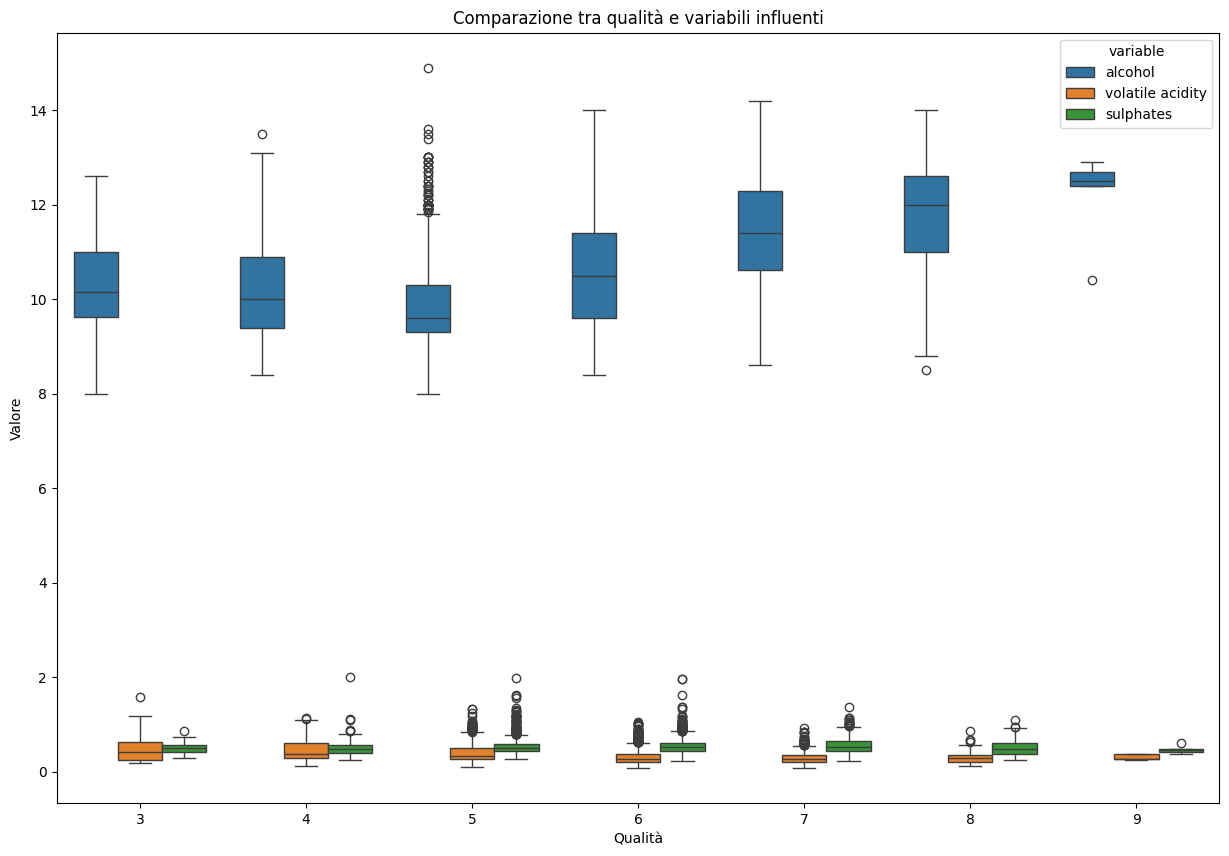

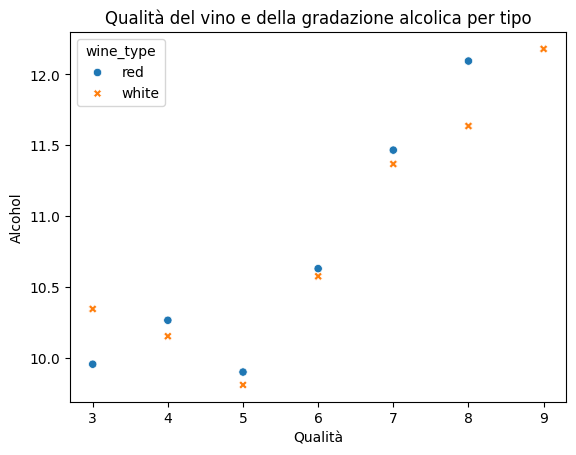

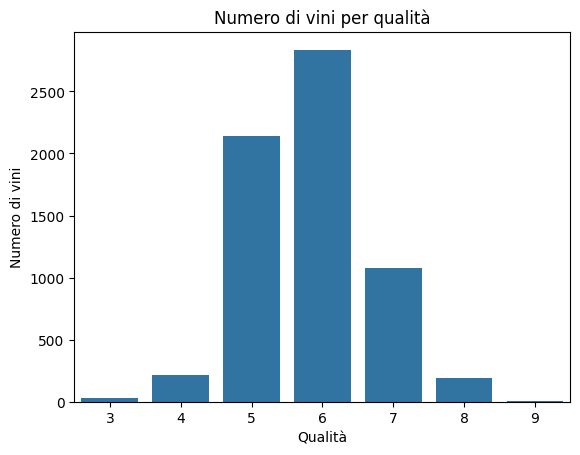



Visualizzazione della tabella pivot dell'acido citrico con una heatmap


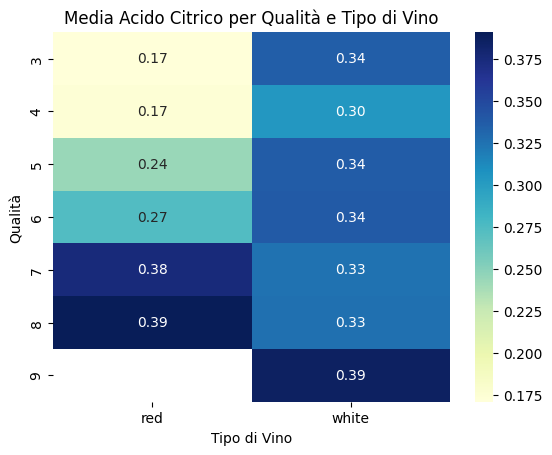



Visualizzazione della tabella pivot della qualita legata alla media Alcoholica con una heatmap


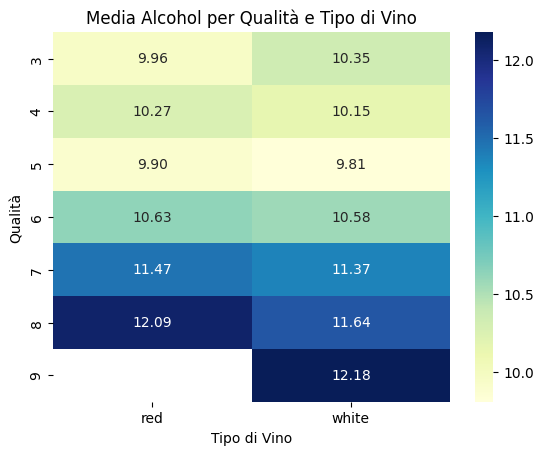



Visualizzazione della tabella pivot della qualità legata alla media dei Solfiti con una heatmap


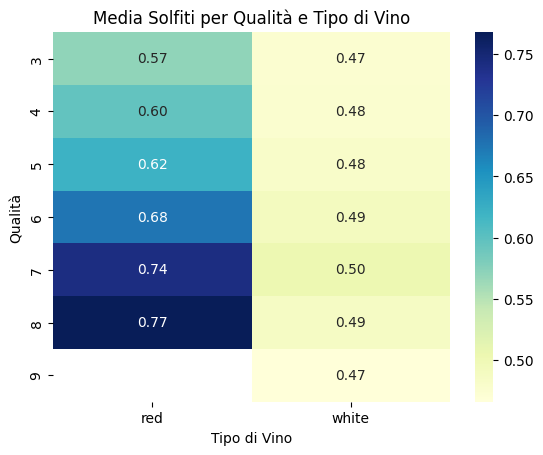



Visualizzazione della qualità legata alla media della Acidità Volatile con una heatmap


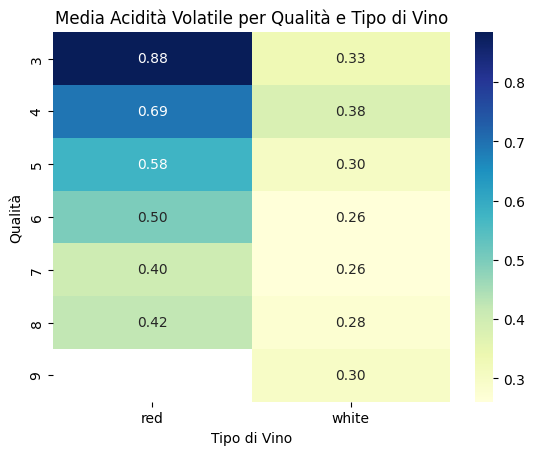



Visualizzazione della qualità legata alla media dello Zucchero Residuo con una heatmap


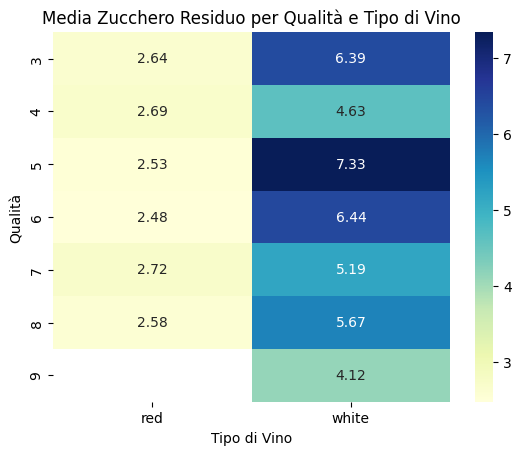



Visualizzazione della qualità legata alla media della SO2 con una heatmap


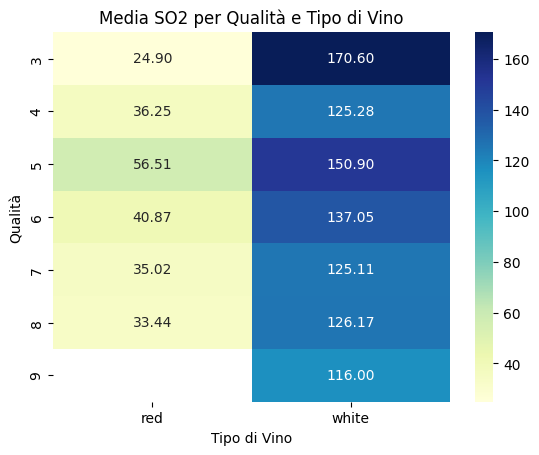



Visualizzazioni delle categorie numeriche tramite Boxplot e Violinplot




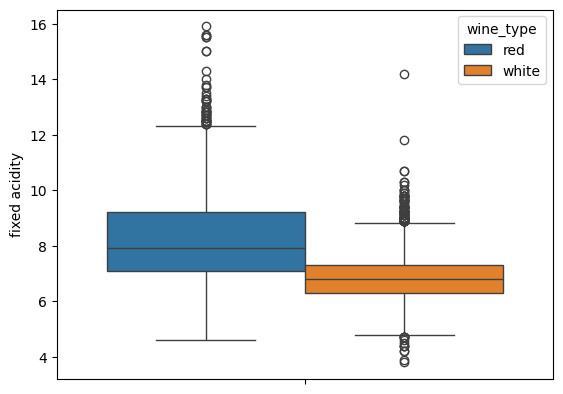

<Figure size 640x480 with 0 Axes>

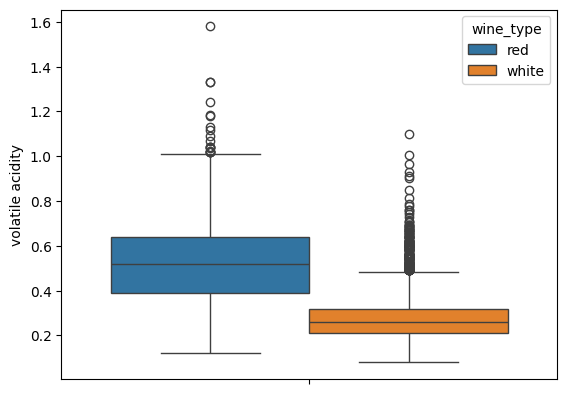

<Figure size 640x480 with 0 Axes>

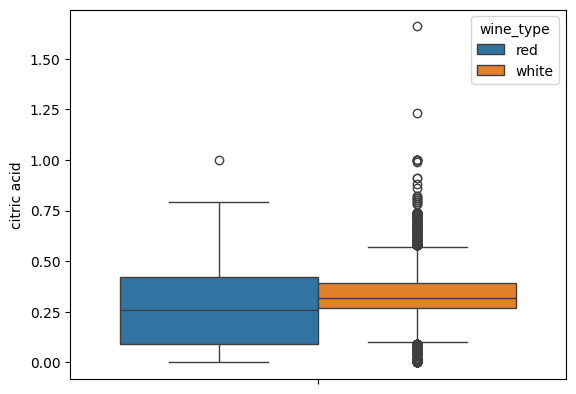

<Figure size 640x480 with 0 Axes>

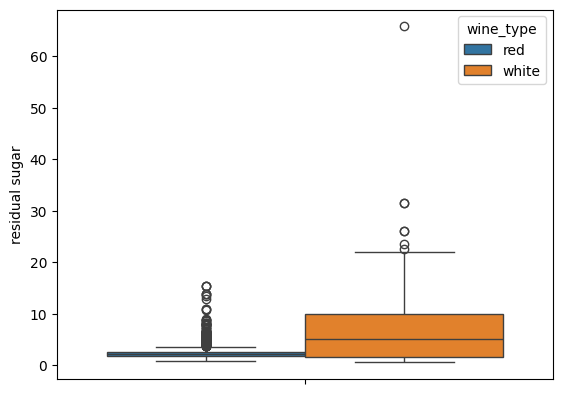

<Figure size 640x480 with 0 Axes>

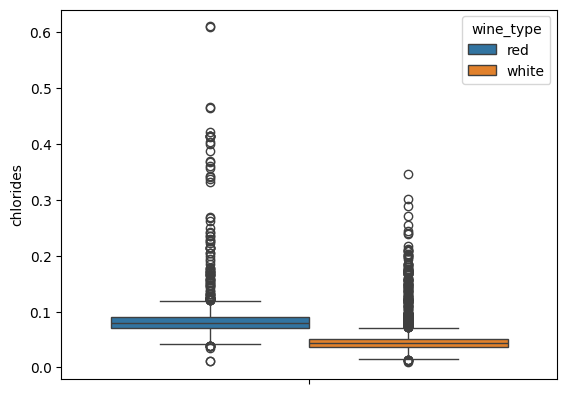

<Figure size 640x480 with 0 Axes>

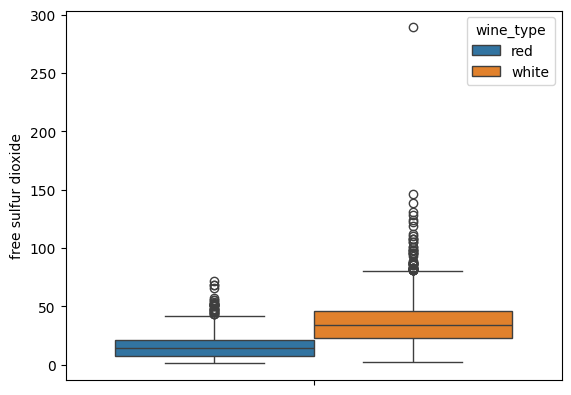

<Figure size 640x480 with 0 Axes>

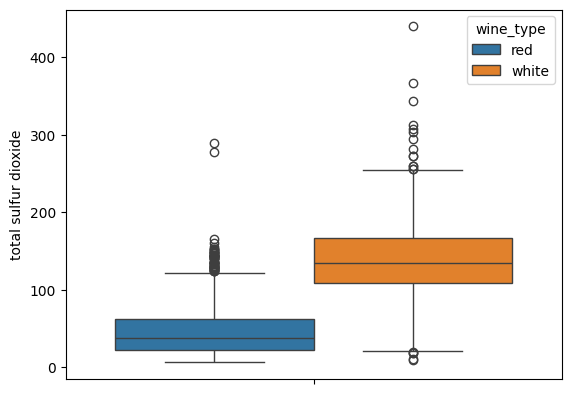

<Figure size 640x480 with 0 Axes>

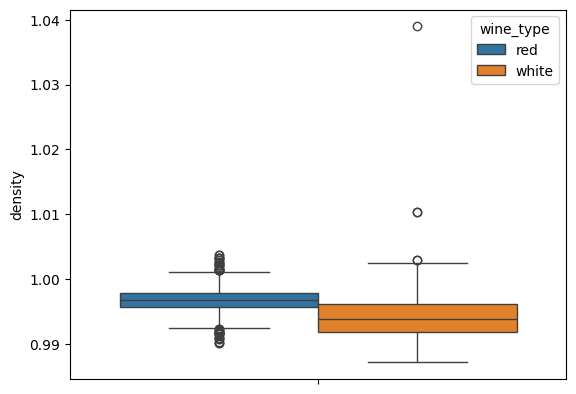

<Figure size 640x480 with 0 Axes>

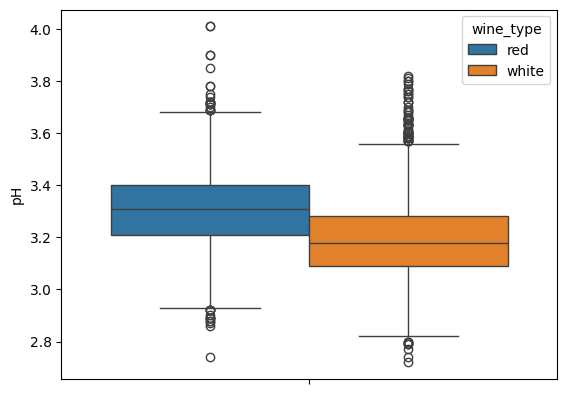

<Figure size 640x480 with 0 Axes>

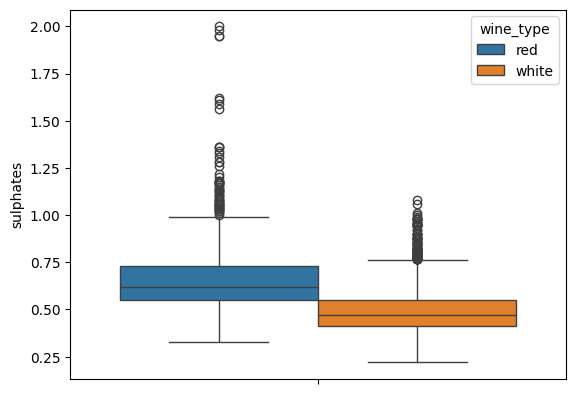

<Figure size 640x480 with 0 Axes>

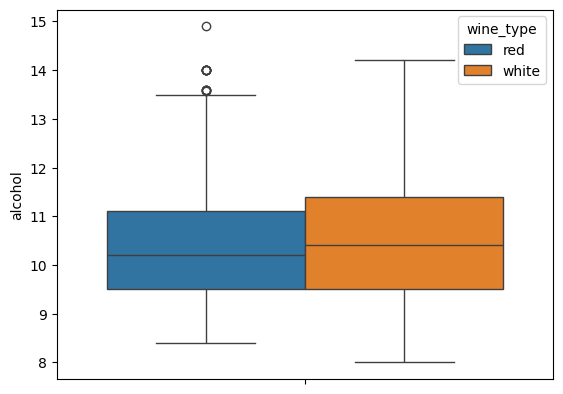

<Figure size 640x480 with 0 Axes>

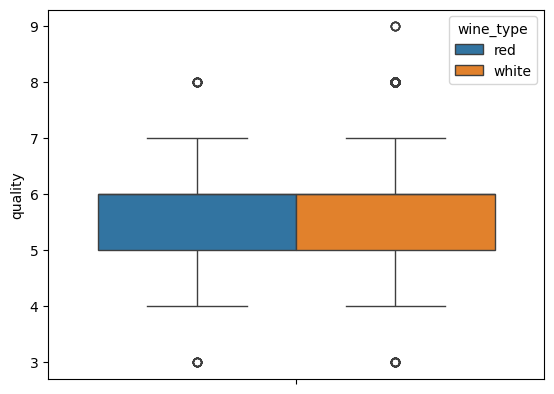

<Figure size 640x480 with 0 Axes>

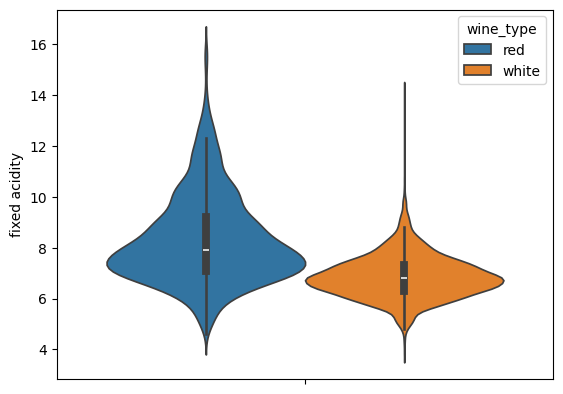

<Figure size 640x480 with 0 Axes>

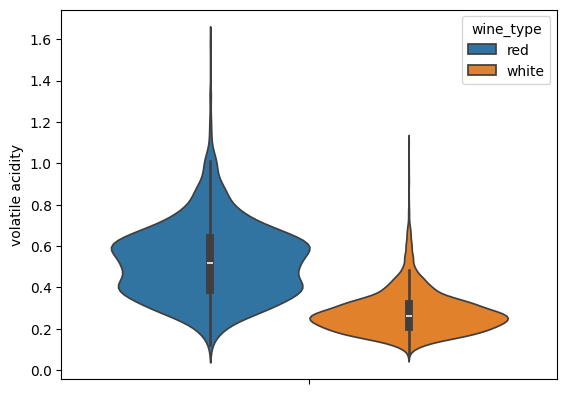

<Figure size 640x480 with 0 Axes>

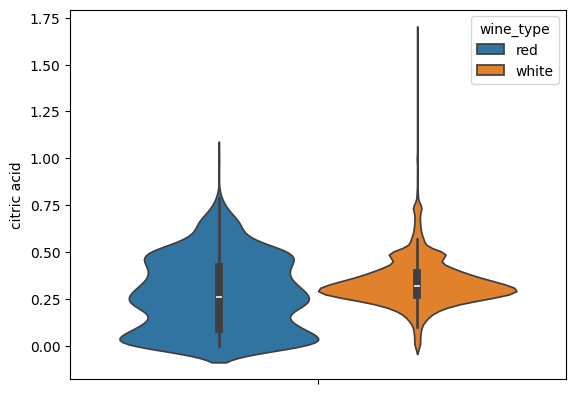

<Figure size 640x480 with 0 Axes>

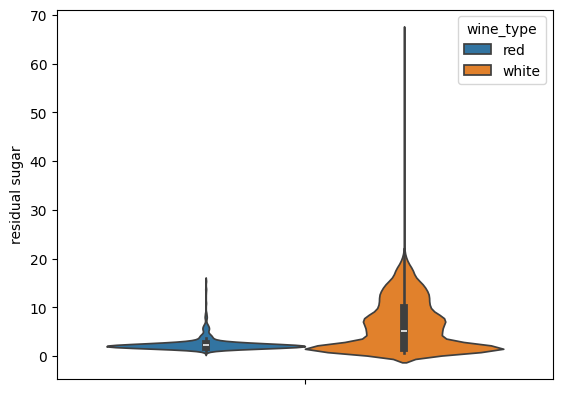

<Figure size 640x480 with 0 Axes>

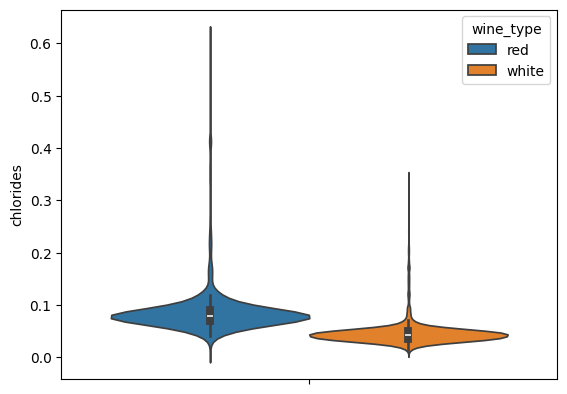

<Figure size 640x480 with 0 Axes>

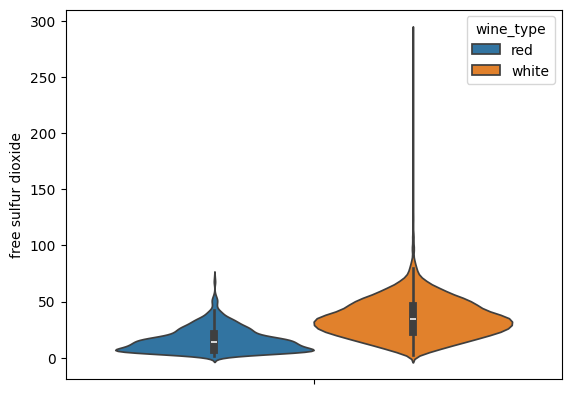

<Figure size 640x480 with 0 Axes>

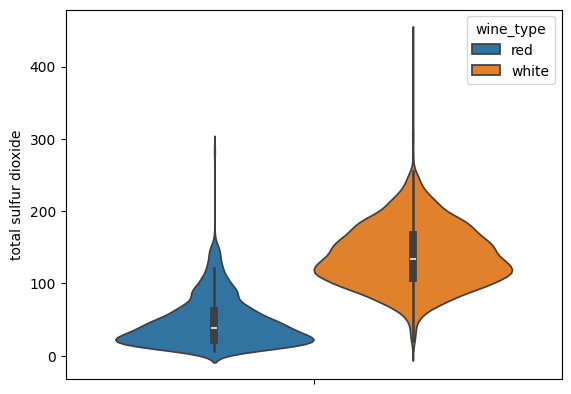

<Figure size 640x480 with 0 Axes>

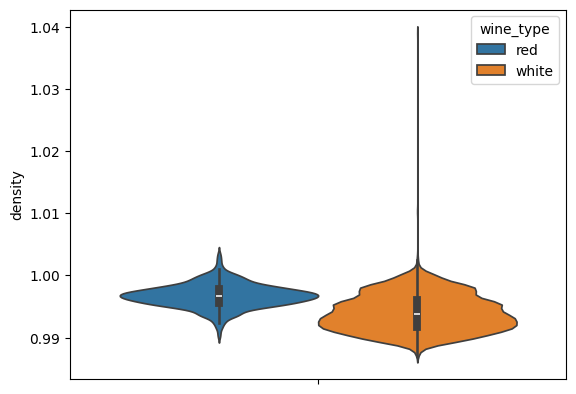

<Figure size 640x480 with 0 Axes>

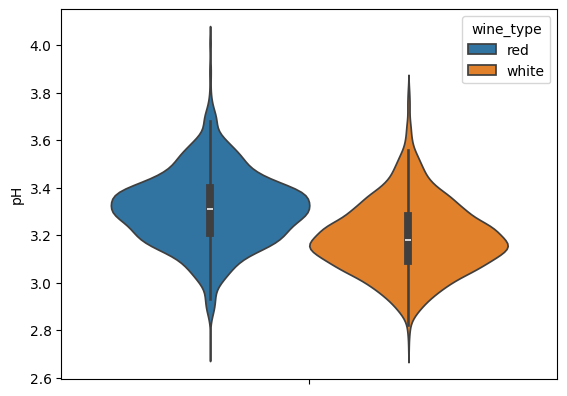

<Figure size 640x480 with 0 Axes>

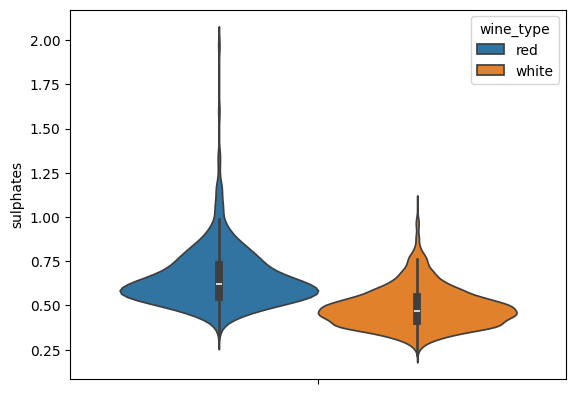

<Figure size 640x480 with 0 Axes>

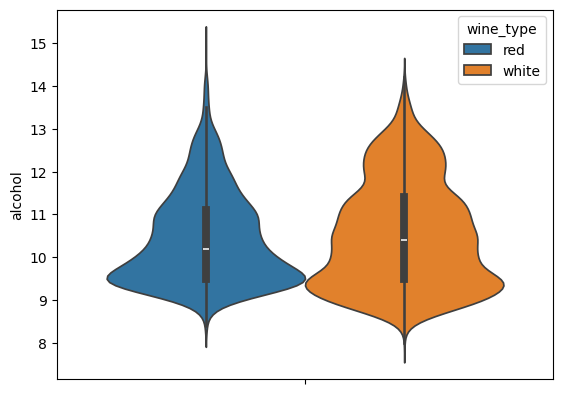

<Figure size 640x480 with 0 Axes>

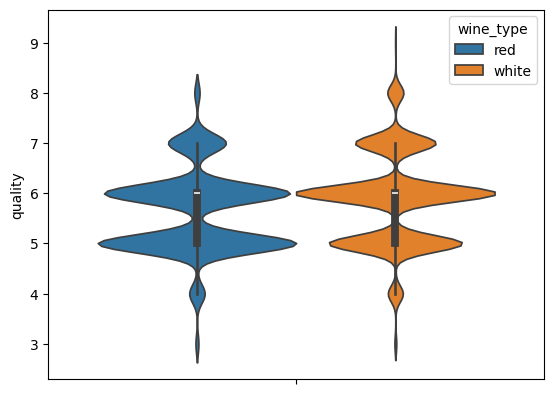

<Figure size 640x480 with 0 Axes>

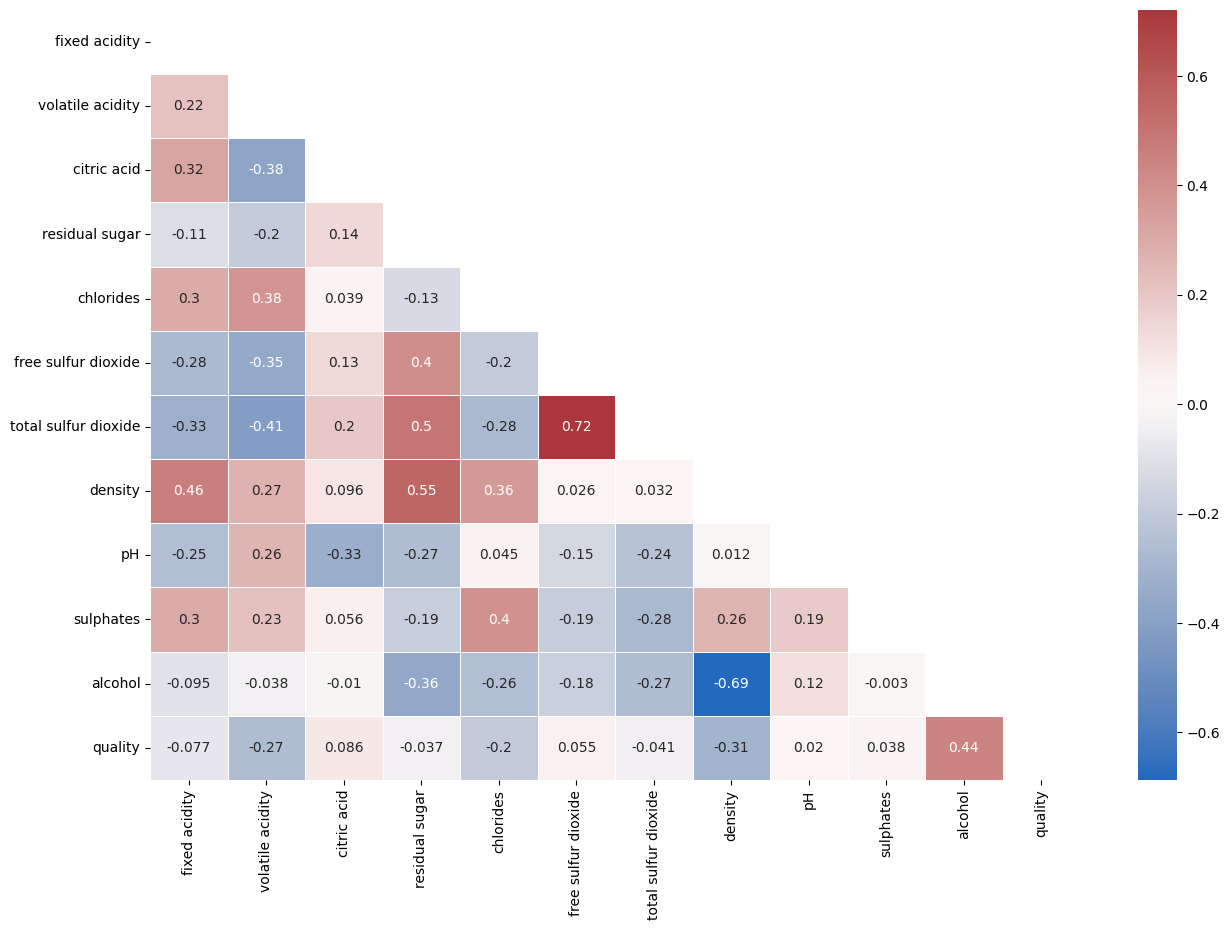

In [ ]:
#Concatenazione con reset_index

df1= pd.concat([ds_red, ds_white], axis=0).reset_index(drop=True)

print(df.shape)
print(df1.shape)

#Tabella Pivot della qualità del vino e della gradazione alcolica per tipo
print(f'Tabella Pivot della qualità legata alla media Alcolica')
pivot = df1.pivot_table(index='quality', columns='wine_type', values='alcohol', aggfunc='mean', observed= False)

print('\n')

display (pivot)

#Tabella Pivot della qualità legata alla media dei Solfiti
print(f'Tabella Pivot della qualità legata alla media dei Solfiti')
pivot2 = df1.pivot_table(index='quality', columns='wine_type', values='sulphates', aggfunc='mean', observed= False)

print('\n')

display (pivot2)

#Tabella Pivot della qualità legata alla media della Acidità Volatile
print(f'Tabella Pivot della qualità legata alla media della Acidità Volatile')
pivot3 = df1.pivot_table(index='quality', columns='wine_type', values='volatile acidity', aggfunc='mean', observed= False)

print('\n')

display (pivot3)

#Tabella pivot per acido citrico legato alla qualità per media di Acido Citrico

print('\n')

print(f'Comparazione Qualità per Media di Acido Citrico')

tabella_pivot = df1.pivot_table(index='quality', columns='wine_type', values='citric acid', aggfunc='mean', observed= False)
display(tabella_pivot)

print('\n')

# Creazione della Tabella Pivot per Qualità legata alla media di Zucchero Residuo
print(f'Tabella Pivot per Qualità legata alla media di Zucchero Residuo')
pivot4 = df1.pivot_table (columns='wine_type', values='residual sugar', index='quality', aggfunc='mean',observed= False)
display(pivot4)

print('\n')

# Mostra la media di alcol e acidità volatile per ogni punteggio di qualità
print(f'Mostra la media di alcol e acidità volatile per ogni punteggio di qualità')

influenza_qualita = df1.groupby('quality')[['alcohol', 'volatile acidity', 'sulphates']].mean()
print(influenza_qualita)

print('\n')

# Calcola la correlazione di tutte le colonne rispetto alla colonna 'quality'
print(f'Calcola la correlazione di tutte le colonne rispetto alla colonna quality')

correlazione = df1.select_dtypes(include=np.number).corr()['quality'].sort_values(ascending=False)
print(correlazione)

print('\n')

# "Srotoliamo" il dataset mantenendo la qualità come variabile di riferimento

print(f'Melt del dataset mantenendo la qualità come variabile di riferimento')

df_melted = df1.melt(id_vars='quality', value_vars=['alcohol', 'volatile acidity', 'sulphates'])

print(df_melted.head())

print('\n')



# Creazione di un grafico comparativo

print(f'Creazione di un grafico comparativo')
plt.figure(figsize=(15, 10))
sns.boxplot(x='quality', y='value', hue='variable', data=df_melted)
plt.title('Comparazione tra qualità e variabili influenti')
plt.xlabel('Qualità')
plt.ylabel('Valore')
plt.show()

print('\n')

sns.scatterplot(pivot)
plt.title('Qualità del vino e della gradazione alcolica per tipo')
plt.xlabel('Qualità')
plt.ylabel('Alcohol')
plt.show()

print('\n')

sns.countplot(x='quality', data=df1,)
plt.title('Numero di vini per qualità')
plt.xlabel('Qualità')
plt.ylabel('Numero di vini')
plt.show()

print('\n')

# Visualizzazione della tabella pivot dell'acido citrico con una heatmap
print(f'Visualizzazione della tabella pivot dell\'acido citrico con una heatmap')
sns.heatmap(tabella_pivot, annot=True, cmap='YlGnBu', fmt=".2f")
plt.title('Media Acido Citrico per Qualità e Tipo di Vino')
plt.xlabel('Tipo di Vino')
plt.ylabel('Qualità')
plt.show()

print('\n')

# Visualizzazione della tabella pivot della qualità legata alla media dell'Alcohol con una heatmap
print(f'Visualizzazione della tabella pivot della qualita legata alla media Alcoholica con una heatmap')
sns.heatmap(pivot, annot=True, cmap='YlGnBu', fmt=".2f")
plt.title('Media Alcohol per Qualità e Tipo di Vino')
plt.xlabel('Tipo di Vino')
plt.ylabel('Qualità')
plt.show()

print('\n')

# Visualizzazione della tabella pivot della qualità legata alla media dei Solfiti con una heatmap
print(f'Visualizzazione della tabella pivot della qualità legata alla media dei Solfiti con una heatmap')
sns.heatmap(pivot2, annot=True, cmap='YlGnBu', fmt=".2f")
plt.title('Media Solfiti per Qualità e Tipo di Vino')
plt.xlabel('Tipo di Vino')
plt.ylabel('Qualità')
plt.show()

print('\n')

# Visualizzazione della qualità legata alla media della Acidità Volatile con una heatmap
print(f'Visualizzazione della qualità legata alla media della Acidità Volatile con una heatmap')
sns.heatmap(pivot3, annot=True, cmap='YlGnBu', fmt=".2f")
plt.title('Media Acidità Volatile per Qualità e Tipo di Vino')
plt.xlabel('Tipo di Vino')
plt.ylabel('Qualità')
plt.show()

print('\n')

# Visualizzazione della qualità legata alla media dello Zucchero Residuo con una heatmap
print(f'Visualizzazione della qualità legata alla media dello Zucchero Residuo con una heatmap')
sns.heatmap(pivot4, annot=True, cmap='YlGnBu', fmt=".2f")
plt.title('Media Zucchero Residuo per Qualità e Tipo di Vino')
plt.xlabel('Tipo di Vino')
plt.ylabel('Qualità')
plt.show()

# Visualizzazione della qualità legata alla media della SO2 con una heatmap

heatmap_so2 = df1.pivot_table(
    values='total sulfur dioxide',
    index='quality',
    columns='wine_type',
    aggfunc='mean',
    observed=False
)

print('\n')

print(f'Visualizzazione della qualità legata alla media della SO2 con una heatmap')
sns.heatmap(heatmap_so2, annot=True, cmap='YlGnBu', fmt=".2f")
plt.title('Media SO2 per Qualità e Tipo di Vino')
plt.xlabel('Tipo di Vino')
plt.ylabel('Qualità')
plt.show()

print('\n')

print(f'Visualizzazioni delle categorie numeriche tramite Boxplot e Violinplot')

print('\n')

for i in num_cols:
    ax = sns.boxplot(data=df1, y=df[i], hue='wine_type', legend=True)
    plt.figure(i);
    plt.show()

print('\n')

for i in num_cols:
    ax = sns.violinplot(data=df1, y=df[i],hue='wine_type', legend=True)
    plt.figure(i);
    plt.show()

print('\n')

# Metodo per una migliore leggibilità delle correlazioni

corrmat = df1[num_cols].corr()

mask = np.triu(np.ones_like(corrmat, dtype=bool))

plt.figure(figsize=(15, 10))
sns.heatmap(
    corrmat,
    annot=True,
    mask=mask,
    cmap='vlag',
    linewidths=0.5
)
plt.show()

**Caratteristiche con maggiore influenza:**

Alcol: È il fattore più determinante per l'alta qualità.
Nelle fonti, i vini classificati con punteggio 8 hanno quasi sempre una gradazione alcolica elevata, spesso superiore al 12-14%

. Al contrario, i vini di bassa qualità (punteggio 3 o 4) tendano ad avere livelli di alcol molto più bassi, spesso inferiori al 10%

. Acidità Volatile (acido acetico): Ha un'influenza negativa molto forte. Alti livelli di acidità volatile sono sistematicamente associati ai punteggi più bassi (Qualità 3). Ad esempio, i campioni con punteggi bassi mostrano valori come 1.185 g/dm³ o 1.58 g/dm³

. I vini di alta qualità mantengono invece questo valore molto basso (spesso sotto lo 0.4 g/dm³)

. Solfati: Specialmente nel vino rosso, i vini di qualità superiore (7-8) mostrano spesso concentrazioni di solfati più elevate (es. 0.86 - 0.92 g/dm³) rispetto a quelli mediocri

. Acido Citrico: La sua presenza è spesso legata alla "freschezza" nei vini di alta qualità

**Ecco le principali divergenze tra vini rossi e vini bianchi riscontrate nei dati:**

. Zucchero Residuo e Anidride Solforosa
La differenza più evidente riguarda il contenuto di zucchero e conservanti:
Zucchero Residuo: I vini bianchi mostrano livelli molto più elevati, raggiungendo punte di 20.7 g/dm³

. Al contrario, i campioni di vino rosso analizzati mostrano valori molto contenuti, spesso compresi tra 1.6 e 2.6 g/dm³

. Anidride Solforosa Totale: I vini bianchi richiedono o contengono dosi molto più alte di questo conservante, con valori che superano frequentemente i 150-170 mg/dm³
. Nei vini rossi, i livelli sono drasticamente più bassi, spesso situati sotto i 70 mg/dm³

**Come variano le caratteristiche chimiche in base alle diverse fasce di qualità del vino**

L'analisi dei dataset indica che la qualità del vino, sia rosso che bianco, è strettamente legata a specifiche proporzioni chimiche. Mentre alcune variabili rimangono costanti, fattori come l'alcol, l'acidità volatile e i solfati mostrano variazioni nette tra i vini di bassa e alta qualità.

1. Fascia di Alta Qualità (Punteggi 7, 8 e 9)
I vini classificati nelle fasce d'eccellenza mostrano tratti chimici distintivi e ricorrenti:
Elevato contenuto alcolico: È il predittore positivo più forte. Nei vini rossi di qualità 8, i livelli di alcol superano spesso il 12-13% (fino a 14.9%)
. Anche nei vini bianchi di qualità 9, la gradazione alcolica è costantemente alta, attestandosi tra il 12.4% e il 12.9%

.Bassa acidità volatile: I vini migliori mantengono livelli molto contenuti di acido acetico. Nei rossi di qualità 8, i valori sono spesso compresi tra 0.26 e 0.42 g/dm³
. Nei bianchi di qualità 9, l'acidità volatile oscilla tra 0.24 e 0.36 g/dm³

.Presenza di acido citrico e solfati (specialmente nei rossi): I vini rossi di alta qualità tendono ad avere livelli significativi di acido citrico (es. 0.45-0.72 g/dm³)
 e concentrazioni di solfati più elevate, spesso sopra lo 0.70 g/dm³

2. Fascia di Bassa Qualità (Punteggi 3 e 4)
I vini con i punteggi più bassi presentano anomalie chimiche che ne penalizzano il profilo sensoriale:
Alta acidità volatile: È il principale segnale di scarsa qualità. Nei vini rossi di qualità 3, si riscontrano picchi estremi di acidità volatile come 1.185 g/dm³ o addirittura 1.58 g/dm³
. Anche i bianchi di qualità 3 mostrano spesso valori superiori alla norma (es. 0.64 g/dm³)

. Gradazione alcolica ridotta: Molti campioni di bassa qualità presentano livelli di alcol inferiori al 10%, spesso vicini all'8.4-9%

. Carenza di acido citrico: Diversi vini rossi classificati con punteggio 3 mostrano un contenuto di acido citrico pari a 0 g/dm³

3. Altre variabili e differenze strutturali
pH: Non sembra esserci una correlazione lineare univoca con la qualità, poiché campioni eccellenti si trovano sia a pH bassi (2.74-2.88)
 che più alti (3.3-3.4)

. Zucchero Residuo: Nei vini bianchi, la qualità massima (9) non è esclusiva dei vini secchi; si trovano campioni eccellenti sia con poco zucchero (1.2-1.6 g/dm³) che con livelli più alti (10.6 g/dm³)

. Anidride Solforosa: I vini bianchi di alta qualità mantengono un controllo rigoroso sulla total sulfur dioxide, con valori che possono variare significativamente ma che restano bilanciati per la conservazione (es. 113-139 mg/dm³ per la qualità 9)

. In sintesi, il passaggio dalla bassa all'alta qualità è segnato da un aumento dell'alcol e dei solfati, accompagnato da una drastica riduzione dell'acidità volatile e da una maggiore presenza di acido citrico.

